# High-Dimensional GMM Visualization (PCA)

This notebook demonstrates how to visualize high-dimensional Gaussian Mixture Models by manually applying PCA for dimensionality reduction before plotting. 

Since the `plot_gmm` function now only supports 2D data, we need to:
1. Apply PCA to reduce high-dimensional data to 2D
2. Fit GMM on the original high-dimensional data
3. Use the 2D PCA-transformed data for visualization

## Workflow:

- **Manual PCA**: We apply PCA ourselves to reduce dimensionality to 2D
- **High-D GMM**: Fit GMM on original high-dimensional data for better model quality
- **2D Visualization**: Use PCA-transformed data for plotting
- **Proper Interpretation**: Show explained variance for better understanding

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_digits, load_wine
from sklearn.preprocessing import StandardScaler
import os

# Change to parent directory to import tgmm
os.chdir('../')

import tgmm

from tgmm import GaussianMixture, plot_gmm, dynamic_figsize

# Set up device and random seeds
device = 'cuda' if torch.cuda.is_available() else 'cpu'
random_state = 42
np.random.seed(random_state)
torch.manual_seed(random_state)

if device == 'cuda':
    torch.cuda.manual_seed(random_state)
    print('CUDA version:', torch.version.cuda)
    print('Device:', torch.cuda.get_device_name(0))
else:
    print('Using CPU')

print(f"TorchGMM version: {tgmm.__version__ if hasattr(tgmm, '__version__') else 'development'}")

Using CPU
TorchGMM version: 0.2.1


## Example: High-Dimensional Synthetic Data

Let's start with synthetic high-dimensional data to demonstrate the PCA functionality.

In [2]:
# Generate high-dimensional synthetic data
n_samples = 1000
n_features = 10
n_centers = 4

# Create high-dimensional clusters
X_high_dim, true_labels = make_blobs(
    n_samples=n_samples,
    centers=n_centers,
    n_features=n_features,
    cluster_std=2.0,
    random_state=random_state
)

# Standardize the data
scaler = StandardScaler()
X_high_dim = scaler.fit_transform(X_high_dim)

print(f"Original data shape: {X_high_dim.shape}")
print(f"Number of clusters: {n_centers}")
print(f"Features range: [{X_high_dim.min():.2f}, {X_high_dim.max():.2f}]")

Original data shape: (1000, 10)
Number of clusters: 4
Features range: [-2.99, 3.03]


In [3]:
# Convert to tensor
X_tensor = torch.tensor(X_high_dim, dtype=torch.float32, device=device)

# Fit GMM on the high-dimensional data
gmm_high_dim = GaussianMixture(
    n_components=n_centers,
    covariance_type='full',
    max_iter=2000,
    random_state=random_state,
    device=device
)

# Fit the model
gmm_high_dim.fit(X_tensor)

# Get predictions
predicted_labels = gmm_high_dim.predict(X_tensor).cpu().numpy()
log_probs = gmm_high_dim.score_samples(X_tensor).cpu().numpy()

# Sample using dimensionally-appropriate radii
sample_50pct, _ = gmm_high_dim.sample(n_samples=500, confidence_range=(0, 0.95))
sample_50pct = sample_50pct.cpu().numpy()

# Sample from the tails (outside 95% radius)
sample_tails, _ = gmm_high_dim.sample(n_samples=500, confidence_range=(0.95, 0.9999999999999))
sample_tails = sample_tails.cpu().numpy()

In [4]:
# Apply PCA to reduce dimensionality for visualization
from sklearn.decomposition import PCA

# Fit PCA on the high-dimensional data
pca = PCA(n_components=2, random_state=random_state)
X_pca = pca.fit_transform(X_high_dim)

# Transform sampled data to PCA space
sample_50pct_pca = pca.transform(sample_50pct)
sample_tails_pca = pca.transform(sample_tails)

# Create a simplified 2D GMM for visualization purposes
# (This is just for plotting - the original high-D GMM is still the "true" model)
X_pca_tensor = torch.tensor(X_pca, dtype=torch.float32, device=device)

# Fit a 2D GMM on the PCA-transformed data for visualization
gmm_2d = GaussianMixture(
    n_components=n_centers,
    covariance_type='full',
    max_iter=1000,
    random_state=random_state,
    device=device
)
gmm_2d.fit(X_pca_tensor)

# Get predictions from the 2D GMM
predicted_labels_2d = gmm_2d.predict(X_pca_tensor).cpu().numpy()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")

PCA explained variance ratio: [0.55261046 0.1964909 ]
Total explained variance: 0.749
PC1 explains 55.3% of variance
PC2 explains 19.6% of variance


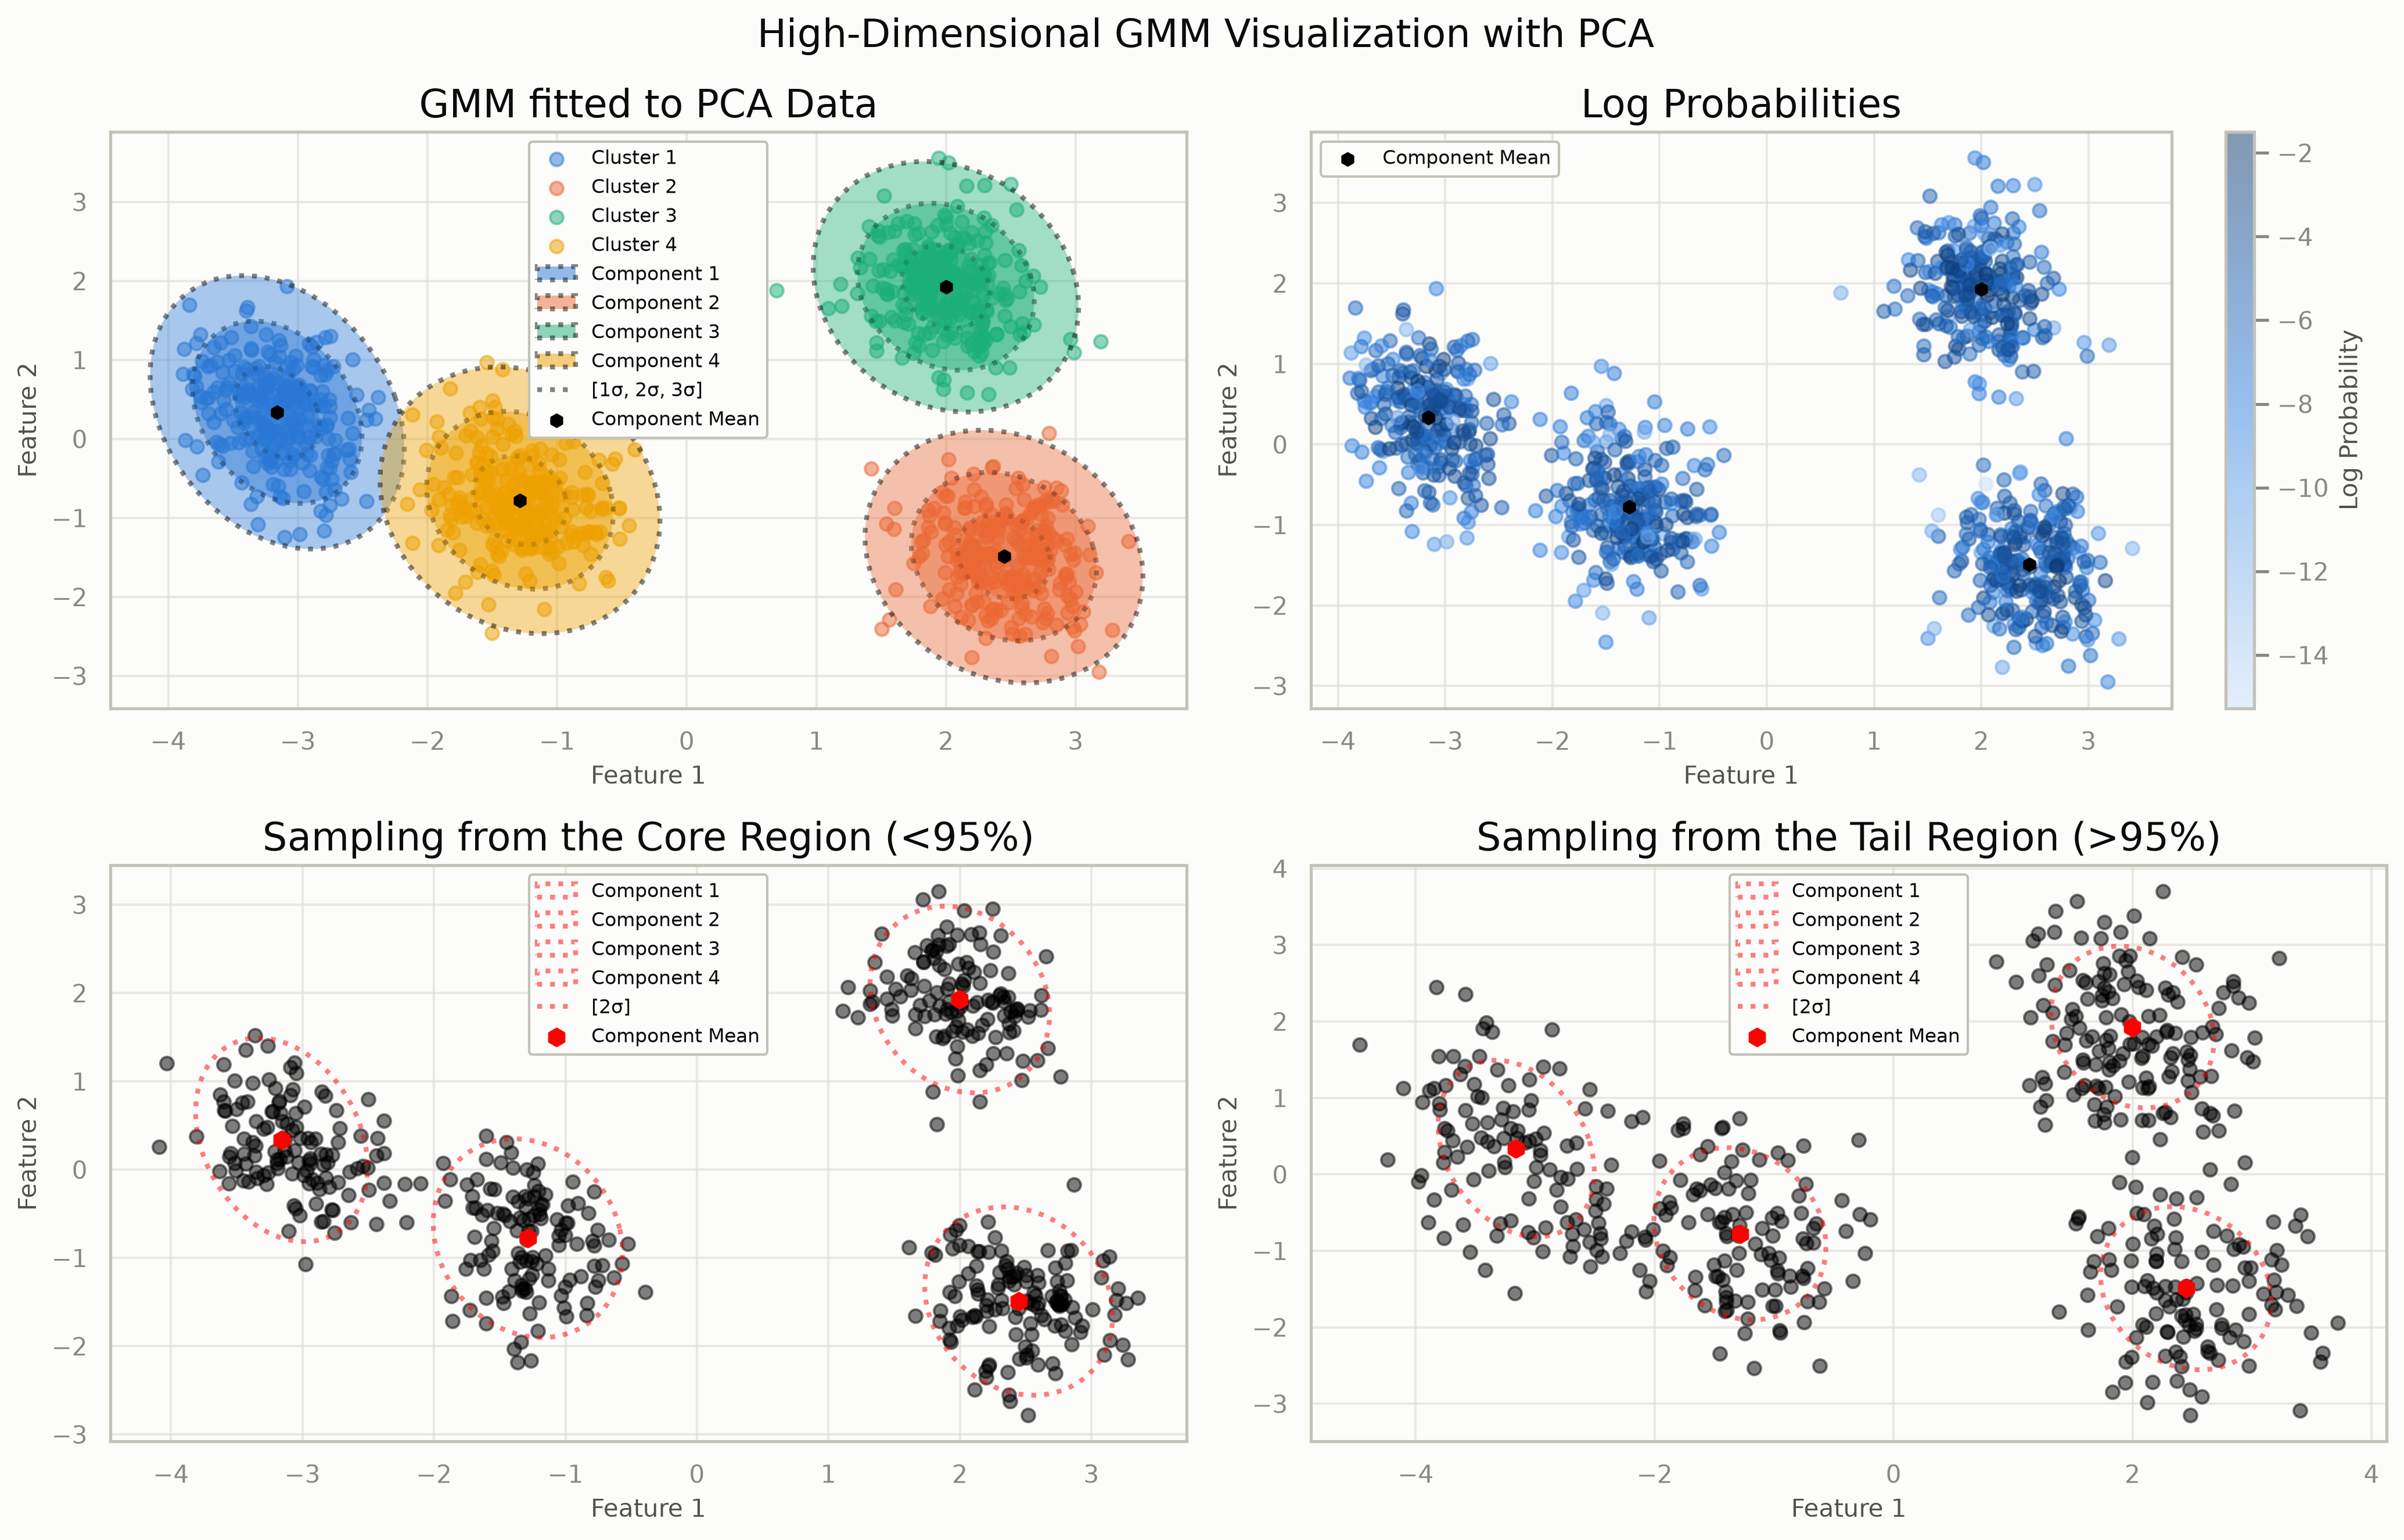

In [5]:
nrows, ncols = 2, 2
figsize = dynamic_figsize(nrows, ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
axes = axes.flatten()
fig.suptitle('High-Dimensional GMM Visualization with PCA', fontsize=16)

# 1. Automatic PCA (default behavior)
plot_gmm(
    X_pca,
    gmm=gmm_2d,
    color_by_cluster=True,
    title='GMM fitted to PCA Data',
    ax=axes[0],
    point_size=30,
)

# 4. Continuous coloring with log probabilities
plot_gmm(
    X_pca,
    gmm=gmm_2d,
    log_probs=log_probs,
    title='Log Probabilities',
    ax=axes[1],
    show_ellipses=False,
    point_size=30,
)

# 5. Sampled points from the GMM (68% region - equivalent to 1-sigma in 1D)
plot_gmm(
    sample_50pct_pca,
    gmm=gmm_2d,
    title=f'Sampling from the Core Region (<95%)',
    ax=axes[2],
    show_ellipses=True,
    ellipse_std_devs=[2],
    ellipse_line_color='red',
    ellipse_fill=False,
    point_size=30,
    mean_color='red',
    mean_size=50
)

# 6. Sampled points from the GMM (tail samples)
plot_gmm(
    sample_tails_pca,
    gmm=gmm_2d,
    title=f'Sampling from the Tail Region (>95%)',
    ax=axes[3],
    show_ellipses=True,
    ellipse_std_devs=[2],
    ellipse_line_color='red',
    ellipse_fill=False,
    point_size=30,
    mean_color='red',
    mean_size=50
)

plt.tight_layout()
plt.show()

### Applying PCA transformation to a GMM vs. fitting a GMM to PCA transformed data

**Theorem**: Let $\{x_i\}_{i=1}^n $ be d-dimensional data, and let $A $ be the PCA transformation matrix to 2D. Then fitting a GMM to the transformed data $\{y_i = Ax_i\} $ yields parameters equivalent to applying the linear transformation to a GMM fitted on the original data.

**Proof**:

Consider a GMM in $d$ dimensions: $p(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x; \mu_k, \Sigma_k) $

After PCA transformation $y = Ax $, each Gaussian component transforms as: $\mathcal{N}(x; \mu_k, \Sigma_k) \rightarrow \mathcal{N}(y; A\mu_k, A\Sigma_k A^T) $

The mixture weights $\pi_k $ remain unchanged since they represent probabilities that are invariant under linear transformation.

The log-likelihood function transforms as:
$\log L(\theta|y) = \sum_{i=1}^n \log \left[ \sum_{k=1}^K \pi_k \mathcal{N}(y_i; A\mu_k, A\Sigma_k A^T) \right] $

Since the maximum likelihood estimator is **equivariant** under linear transformations for location-scale families , the MLE parameters satisfy:

- $\hat{\mu}_{k}^{(y)} = A\hat{\mu}_{k}^{(x)} $
- $\hat{\Sigma}_{k}^{(y)} = A\hat{\Sigma}_{k}^{(x)}A^T $
- $\hat{\pi}_{k}^{(y)} = \hat{\pi}_{k}^{(x)} $